# Split data and Preprocess

In [1]:
#Import libraries
import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Set paths & split ratio

biological_dir = '../dataset/biological'
plastic_dir = '../dataset/plastic'

split_dir = '../dataset_split'

# Split ratio: 70% train, 15% val, 15% test
train_ratio = 0.70
val_ratio = 0.15
test_ratio = 0.15

# Target size for all images
target_size = (224, 224)
valid_ext = ('.jpg', '.jpeg', '.bmp', '.webp')

def get_paths(folder):
    return [
        os.path.join(folder, f)
        for f in os.listdir(folder)
        if f.lower().endswith(valid_ext)
    ]

bio_paths = get_paths(biological_dir)
pla_paths = get_paths(plastic_dir)

print(f'Biological : {len(bio_paths)} images')
print(f'Plastic    : {len(pla_paths)} images')
print(f'Split ratio: {int(train_ratio*100)}% train / {int(val_ratio*100)}% val / {int(test_ratio*100)}% test')
print(f'Target size: {target_size[0]}x{target_size[1]} pixels')

Biological : 1042 images
Plastic    : 1042 images
Split ratio: 70% train / 15% val / 15% test
Target size: 224x224 pixels


In [3]:
# Create folder structure
classes = ['biological', 'plastic']
splits = ['train', 'val', 'test']

for split in splits:
    for cls in classes:
        folder = os.path.join(split_dir, split, cls)
        os.makedirs(folder, exist_ok=True)

print(' Folder structure created:')
print('   dataset_split/')
for split in splits:
    print(f'   ├── {split}/')
    for cls in classes:
        print(f'   │    ├── {cls}/')

 Folder structure created:
   dataset_split/
   ├── train/
   │    ├── biological/
   │    ├── plastic/
   ├── val/
   │    ├── biological/
   │    ├── plastic/
   ├── test/
   │    ├── biological/
   │    ├── plastic/


In [4]:
# Split & Resize Function
def split_and_save(img_paths, class_name, seed=42):
    random.seed(seed)
    paths = img_paths.copy()
    random.shuffle(paths)

    total = len(paths)
    train_end = int(total * train_ratio)
    val_end = train_end + int(total * val_ratio)

    split_data = {
        'train' : paths[:train_end],
        'val' : paths[train_end:val_end],
        'test' : paths[val_end:]
    }
    
    counts = {}
    for split, split_paths in split_data.items():
        saved = 0
        for i, src in enumerate(split_paths):
            try:
                img = Image.open(src).convert('RGB')
                img = img.resize(target_size, Image.LANCZOS)
                ext = os.path.splitext(src)[1].lower()
                if ext not in ['.jpg', '.jpeg']:
                    ext = '.jpg'
                fname = f'{class_name}_{split}_{i+1:04d}{ext}'
                dst = os.path.join(split_dir, split, class_name, fname)
                img.save(dst, 'JPEG', quality=95)
                saved += 1
            except Exception as e:
                print(f"Skipped {src}: {e}")
        counts[split] = saved
    
    return counts

In [5]:
# Run split for both classes
print('Processing Biological...')
bio_counts = split_and_save(bio_paths, 'biological')
print(f'  train: {bio_counts["train"]}  val: {bio_counts["val"]}  test: {bio_counts["test"]}')

print('\nProcessing Plastic...')
pla_counts = split_and_save(pla_paths, 'plastic')
print(f'  train: {pla_counts["train"]}  val: {pla_counts["val"]}  test: {pla_counts["test"]}')

Processing Biological...
  train: 729  val: 156  test: 157

Processing Plastic...
  train: 729  val: 156  test: 157


In [6]:
# Verify final count
def count_image(folder):
    total = 0
    for root, dirs, files in os.wald(folder):
        total += sum(1 for f in files if f.lower().endswith(valid_ext))
    return total

print('=' * 55)
print('        SPLIT SUMMARY — SMART BIN DATASET')
print('=' * 55)
print(f"{'Split':<10} {'Biological':>12} {'Plastic':>10} {'Total':>8}")
print('-' * 55)

grand_total = 0
for split in splits:
    bio_n = len(os.listdir(os.path.join(split_dir, split, 'biological')))
    pla_n = len(os.listdir(os.path.join(split_dir, split, 'plastic')))
    tot = bio_n + pla_n
    grand_total += tot
    print(f"{split:<8} {bio_n:>12} {pla_n:>10} {tot:>8}")

        SPLIT SUMMARY — SMART BIN DATASET
Split        Biological    Plastic    Total
-------------------------------------------------------
train             729        729     1458
val               156        156      312
test              157        157      314


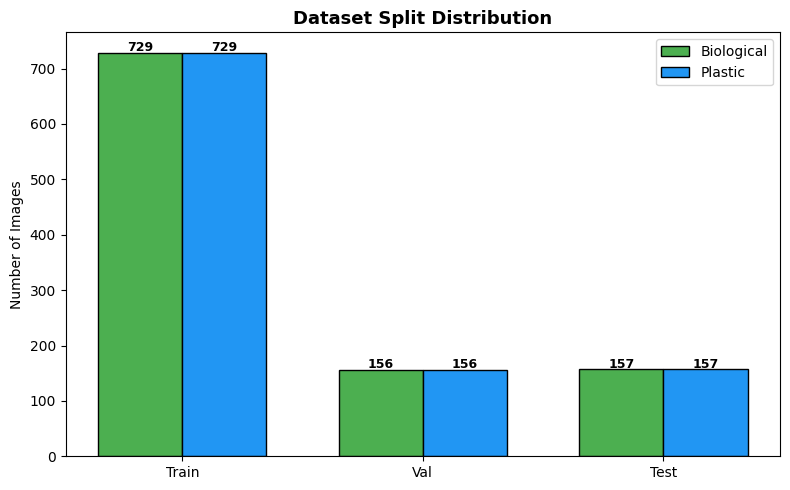

In [7]:
# Bar chat of split distribution
splits_labels = ['Train', 'Val', 'Test']
bio_vals = [bio_counts['train'], bio_counts['val'], bio_counts['test']]
pla_vals = [pla_counts['train'], pla_counts['val'], pla_counts['test']]

x = np.arange(len(splits_labels))
w = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - w/2, bio_vals, w, label='Biological', color='#4CAF50', edgecolor='black')
b2 = ax.bar(x + w/2, pla_vals, w, label='Plastic',    color='#2196F3', edgecolor='black')

ax.set_title('Dataset Split Distribution', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Images')
ax.set_xticks(x)
ax.set_xticklabels(splits_labels)
ax.legend()

for bar in list(b1) + list(b2):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 3,
        str(int(bar.get_height())),
        ha='center', fontsize=9, fontweight='bold'
    )

plt.tight_layout()
plt.show()